In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

plt.style.use("fivethirtyeight")

In [36]:
apartments = pd.read_csv('../data/sarajevo_flats_merged_olx_cleaned.csv')
apartments.head()

,title,url,price_numeric,municipality,condition,ad_type,property_type,rooms,square_m2,equipment,level,heating,price_per_m2
0,Stan Apartman - [Iznajmljivanje],https://olx.ba/artikal/71698283,60.0,Sarajevo - Novi Grad,Novogradnja,Iznajmljivanje,Apartman,2.0,46.0,Namješten,7,Centralno (gradsko),1.304348
1,Stan Sarajevo - Novo Sarajevo - [Iznajmljivanje],https://olx.ba/artikal/71573692,80.0,Sarajevo - Novo Sarajevo,Renoviran,Iznajmljivanje,Apartman,2.0,62.0,Namješten,16,Centralno (gradsko),1.290323
2,Garaza - Nova Vogosca - 20 m2 - [Iznajmljivanje],https://olx.ba/artikal/70756410,100.0,Vogošća,Novogradnja,Iznajmljivanje,Stan,2.0,20.0,Namješten,-1,Centralno (Kotlovnica),5.000000
3,Panorama View Apartman Bjelasnica (Rent) - [Iz...,https://olx.ba/artikal/71554658,160.0,Trnovo,Novogradnja,Iznajmljivanje,Apartman,2.0,50.0,Namješten,0,Struja,3.200000
4,Stanovi i apartmani Sarajevo - Novi Grad - [Iz...,https://olx.ba/artikal/71474528,200.0,Sarajevo - Novi Grad,Dobro stanje,Iznajmljivanje,Apartman,1.0,30.0,Namješten,1,Centralno (Kotlovnica),6.666667


In [37]:
apartments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1806 entries, 0 to 1805
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   title          1806 non-null   object 
 1   url            1806 non-null   object 
 2   price_numeric  1428 non-null   float64
 3   municipality   1806 non-null   object 
 4   condition      1806 non-null   object 
 5   ad_type        1806 non-null   object 
 6   property_type  1806 non-null   object 
 7   rooms          1664 non-null   float64
 8   square_m2      1806 non-null   float64
 9   equipment      1806 non-null   object 
 10  level          1806 non-null   object 
 11  heating        1806 non-null   object 
 12  price_per_m2   1428 non-null   float64
dtypes: float64(4), object(9)
memory usage: 183.6+ KB


In [38]:
apartments["heating"].unique()

array(['Centralno (gradsko)', 'Centralno (Kotlovnica)', 'Struja',
       'Centralno (Plin)', 'Plin', 'Drva', 'Ostalo'], dtype=object)

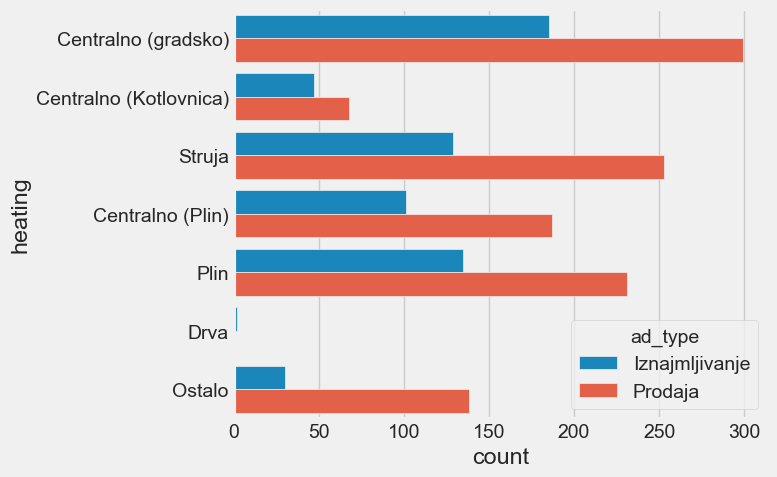

In [39]:
plt.figure(figsize=(8,5))
sns.countplot(data=apartments, y="heating", hue="ad_type")
plt.tight_layout()

<Axes: xlabel='count', ylabel='heating'>

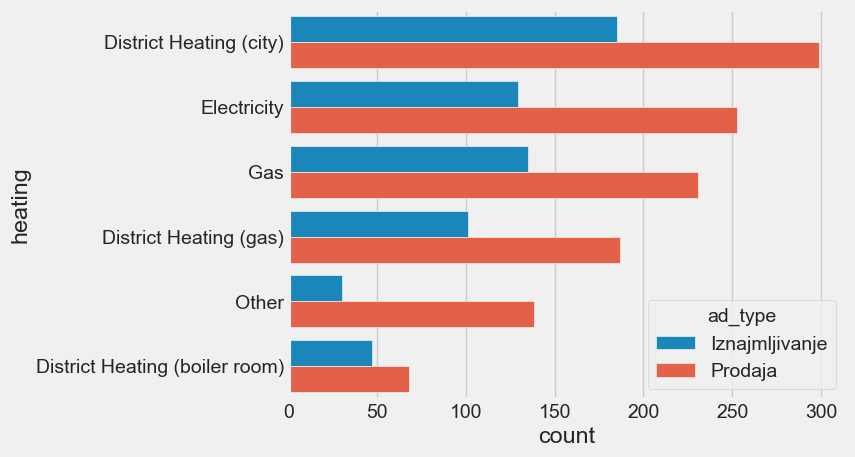

In [40]:
allowed_heating_types = ['Centralno (gradsko)', 'Centralno (Kotlovnica)', 'Struja', 'Centralno (Plin)', 'Plin', 'Ostalo']
rename_dict = {
    "Centralno (gradsko)": "District Heating (city)",
    "Centralno (Kotlovnica)": "District Heating (boiler room)",
    "Centralno (Plin)": "District Heating (gas)",
    "Struja": "Electricity",
    "Plin": "Gas",
    "Ostalo": "Other"
}

disallowed_heating_locations = ~apartments["heating"].isin(allowed_heating_types)

apartments.drop(index=apartments[disallowed_heating_locations].index.values, inplace=True)
apartments["heating"].replace(to_replace=rename_dict, inplace=True)
sns.countplot(data=apartments, y="heating", hue="ad_type", order=apartments["heating"].value_counts().index)

In [44]:
apartments["heating"] = apartments["heating"].astype("category")
apartments.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1803 entries, 0 to 1805
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   title          1803 non-null   object  
 1   url            1803 non-null   object  
 2   price_numeric  1425 non-null   float64 
 3   municipality   1803 non-null   object  
 4   condition      1803 non-null   object  
 5   ad_type        1803 non-null   object  
 6   property_type  1803 non-null   object  
 7   rooms          1661 non-null   float64 
 8   square_m2      1803 non-null   float64 
 9   equipment      1803 non-null   object  
 10  level          1803 non-null   object  
 11  heating        1803 non-null   category
 12  price_per_m2   1425 non-null   float64 
dtypes: category(1), float64(4), object(8)
memory usage: 185.1+ KB


In [45]:
apartments["level"].unique()

array(['7', '16', '-1', '0', '1', '3', '2', '4', '5', '14', '6', '10',
       '13', '15', '-2', '8', '11', '9', '19', '12', '18', '17', '20+',
       '-3'], dtype=object)

In [46]:
apartments[apartments["level"] == "20+"]

,title,url,price_numeric,municipality,condition,ad_type,property_type,rooms,square_m2,equipment,level,heating,price_per_m2
643,Stan Sarajevo - Novo sarajevo,https://olx.ba/artikal/70883958,200000.0,Sarajevo - Novo Sarajevo,Parcijalno renoviran,Prodaja,Stan,2.0,45.00,Polunamješten,20+,District Heating (city),4444.444444
805,NN Nekretnine : Dvosoban stan - Hrasno,https://olx.ba/artikal/71755213,255000.0,Sarajevo - Novi Grad,Za renoviranje,Prodaja,Stan,2.0,56.00,Namješten,20+,District Heating (city),4553.571429
934,MODERNO RENOVIRAN I OPREMLJEN ČETVOROSOBAN STAN,https://olx.ba/artikal/66616379,299900.0,Sarajevo - Novo Sarajevo,Renoviran,Prodaja,Stan,4.0,76.00,Namješten,20+,Electricity,3946.052632
1164,"SARAJEVO TOWER STAN 71,50 m2",https://olx.ba/artikal/68255376,399000.0,Sarajevo - Centar,Novogradnja,Prodaja,Stan,3.0,71.50,Nenamješten,20+,District Heating (city),5580.419580
1324,Biro HM/ Sarajevo Tower trosoban stan 99m2,https://olx.ba/artikal/71750719,550000.0,Sarajevo - Novo Sarajevo,Novogradnja,Prodaja,Stan,3.0,99.00,Namješten,20+,District Heating (gas),5555.555556
1325,HITNO!!! Trosoban Stan Sarajevo Tower,https://olx.ba/artikal/69004499,550000.0,Sarajevo - Novo Sarajevo,Novogradnja,Prodaja,Stan,3.0,92.00,Namješten,20+,District Heating (city),5978.260870
1326,MY SPACE/ Stan/ Sarajevo Tower/ NOVOGRADNJA/ N...,https://olx.ba/artikal/69072756,550000.0,Sarajevo - Novo Sarajevo,Novogradnja,Prodaja,Stan,3.0,92.00,Namješten,20+,District Heating (city),5978.260870
1382,"CASA MIA / Penthouse / 145,55 m2 / Sarajevo Tower",https://olx.ba/artikal/67622446,698640.0,Sarajevo - Novo Sarajevo,Novogradnja,Prodaja,Stan,NaN,145.55,Nenamješten,20+,Other,4800.000000
1390,NN Nekretnine : Dvoetažni penthouse 145m2 - Sa...,https://olx.ba/artikal/66440777,713195.0,Sarajevo - Novo Sarajevo,Novogradnja,Prodaja,Stan,NaN,145.55,Nenamješten,20+,District Heating (city),4900.000000
1409,"CASA MIA / Penthouse / 192,53 m2 / Sarajevo Tower",https://olx.ba/artikal/67622950,924144.0,Sarajevo - Novo Sarajevo,Novogradnja,Prodaja,Stan,4.0,192.53,Nenamješten,20+,Other,4800.000000


<Axes: xlabel='level', ylabel='count'>

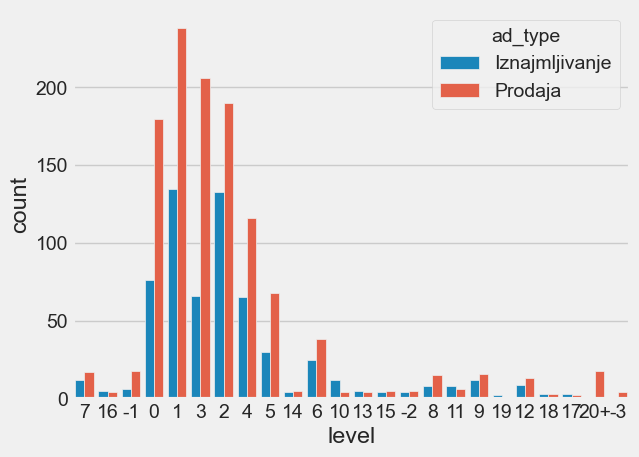

In [66]:
sns.countplot(data=apartments, x="level", hue="ad_type", order=apartments["level"].unique().sort())

ValueError: Unable to parse string "20+" at position 22